# Notebook 3: ML Baseline Models

**Models:** Logistic Regression, Random Forest, XGBoost, LightGBM, MLP

**Objectives:**
- Train traditional ML models on node features (no graph structure)
- Evaluate with fraud-focused metrics
- Store results for comparison with GNN models

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              average_precision_score, f1_score,
                              precision_score, recall_score, accuracy_score)
import xgboost as xgb
import lightgbm as lgb

from graph_builder import load_graph
from utils import set_seed

set_seed(42)
%matplotlib inline

## 1. Load Graph Data and Extract Features

In [2]:
data = load_graph('../data/processed')

X = data.x.numpy()
y = data.y.numpy()

X_train = X[data.train_mask.numpy()]
y_train = y[data.train_mask.numpy()]
X_val   = X[data.val_mask.numpy()]
y_val   = y[data.val_mask.numpy()]
X_test  = X[data.test_mask.numpy()]
y_test  = y[data.test_mask.numpy()]

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Fraud rate in test: {y_test.mean()*100:.1f}%')

Train: (29800, 166), Val: (7451, 166), Test: (9313, 166)
Fraud rate in test: 9.8%


## 2. Helper: Evaluate and Store Metrics

In [3]:
results = {}

def evaluate_clf(name, clf, X_test, y_test):
    pred  = clf.predict(X_test)
    prob  = clf.predict_proba(X_test)[:, 1]
    metrics = {
        'accuracy' : accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall'   : recall_score(y_test, pred, zero_division=0),
        'f1'       : f1_score(y_test, pred, zero_division=0),
        'roc_auc'  : roc_auc_score(y_test, prob),
        'pr_auc'   : average_precision_score(y_test, prob),
    }
    results[name] = metrics
    print(f'\n=== {name} ===')
    print(classification_report(y_test, pred, target_names=['Licit','Illicit']))
    print(f'  ROC-AUC: {metrics["roc_auc"]:.4f}  |  PR-AUC: {metrics["pr_auc"]:.4f}')
    return prob

## 3. Logistic Regression

In [4]:
lr = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
lr.fit(X_train, y_train)
lr_prob = evaluate_clf('Logistic Regression', lr, X_test, y_test)


=== Logistic Regression ===
              precision    recall  f1-score   support

       Licit       0.99      0.87      0.93      8404
     Illicit       0.44      0.93      0.60       909

    accuracy                           0.88      9313
   macro avg       0.72      0.90      0.76      9313
weighted avg       0.94      0.88      0.90      9313

  ROC-AUC: 0.9649  |  PR-AUC: 0.7546


## 4. Random Forest

In [5]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
rf_prob = evaluate_clf('Random Forest', rf, X_test, y_test)


=== Random Forest ===
              precision    recall  f1-score   support

       Licit       0.99      1.00      0.99      8404
     Illicit       1.00      0.88      0.93       909

    accuracy                           0.99      9313
   macro avg       0.99      0.94      0.96      9313
weighted avg       0.99      0.99      0.99      9313

  ROC-AUC: 0.9966  |  PR-AUC: 0.9817


## 5. XGBoost

In [6]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb_clf = xgb.XGBClassifier(
    n_estimators=300, scale_pos_weight=scale_pos,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, n_jobs=-1
)
xgb_clf.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_prob = evaluate_clf('XGBoost', xgb_clf, X_test, y_test)


=== XGBoost ===
              precision    recall  f1-score   support

       Licit       0.99      1.00      1.00      8404
     Illicit       0.99      0.93      0.96       909

    accuracy                           0.99      9313
   macro avg       0.99      0.97      0.98      9313
weighted avg       0.99      0.99      0.99      9313

  ROC-AUC: 0.9974  |  PR-AUC: 0.9872


## 6. LightGBM

In [7]:
lgb_clf = lgb.LGBMClassifier(
    n_estimators=300, class_weight='balanced',
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_clf.fit(X_train, y_train)
lgb_prob = evaluate_clf('LightGBM', lgb_clf, X_test, y_test)


=== LightGBM ===
              precision    recall  f1-score   support

       Licit       0.99      1.00      1.00      8404
     Illicit       0.99      0.94      0.96       909

    accuracy                           0.99      9313
   macro avg       0.99      0.97      0.98      9313
weighted avg       0.99      0.99      0.99      9313

  ROC-AUC: 0.9982  |  PR-AUC: 0.9895


## 7. MLP

In [8]:
mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42)
mlp.fit(X_train, y_train)
mlp_prob = evaluate_clf('MLP', mlp, X_test, y_test)


=== MLP ===
              precision    recall  f1-score   support

       Licit       0.99      0.99      0.99      8404
     Illicit       0.94      0.86      0.90       909

    accuracy                           0.98      9313
   macro avg       0.96      0.93      0.94      9313
weighted avg       0.98      0.98      0.98      9313

  ROC-AUC: 0.9856  |  PR-AUC: 0.9408


## 8. Baseline Results Summary

In [9]:
df_results = pd.DataFrame(results).T.round(4)
print(df_results.to_string())
df_results.to_csv('../results/baseline_metrics.csv')

                     accuracy  precision  recall      f1  roc_auc  pr_auc
Logistic Regression    0.8783     0.4414  0.9285  0.5984   0.9649  0.7546
Random Forest          0.9875     0.9962  0.8757  0.9321   0.9966  0.9817
XGBoost                0.9928     0.9930  0.9329  0.9620   0.9974  0.9872
LightGBM               0.9927     0.9873  0.9373  0.9616   0.9982  0.9895
MLP                    0.9811     0.9379  0.8636  0.8992   0.9856  0.9408


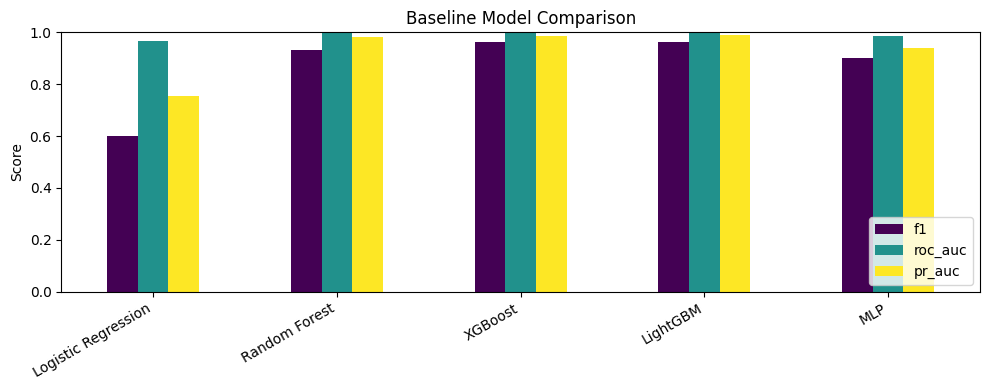

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
df_results[['f1','roc_auc','pr_auc']].plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('Baseline Model Comparison')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../results/figures/baseline_comparison.png', dpi=150)
plt.show()